# How do I create plots using Pandas and the Matplotlib library?

This guide demonstrates how to create visualizations directly from Pandas DataFrames.   Pandas has built-in plotting capabilities that use Matplotlib, making it easy to quickly visualize your meteorological data.

**What you'll learn:**
- Basic plot types (line, scatter, bar, histogram, box plots)
- Customizing plots (colors, labels, titles, legends)
- Creating multiple subplots
- Time series visualization
- Advanced meteorological plotting techniques
- Saving plots for reports and presentations

## Setup

First, let's import our libraries and configure the plotting environment:

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# This command makes plots appear in the notebook
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style for better-looking default plots
plt.style.use('seaborn-v0_8-darkgrid')

# Set default figure size (width, height in inches)
plt.rcParams['figure.figsize'] = (12, 6)

print("Setup complete! ")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib backend: {plt.get_backend()}")

Setup complete! 
Pandas version: 2.2.3
Matplotlib backend: inline


## Create Sample Weather Dataset

Let's create a realistic weather dataset for our examples:

In [2]:
# Create one year of daily weather data
dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
n_days = len(dates)

# Generate realistic seasonal temperature pattern
# Temperature follows a sinusoidal pattern throughout the year
day_of_year = np.arange(n_days)
base_temp = 12  # Annual average temperature in Celsius
seasonal_amplitude = 10  # Temperature swing from winter to summer
seasonal_temp = base_temp + seasonal_amplitude * np.sin((day_of_year - 80) * 2 * np.pi / 365)
temperature = seasonal_temp + np.random.normal(0, 3, n_days)

# Generate other weather variables
humidity = 60 + 20 * np. sin((day_of_year - 80) * 2 * np.pi / 365 + np.pi / 4) + np.random.normal(0, 10, n_days)
humidity = np.clip(humidity, 20, 100)  # Keep humidity between 20-100%

pressure = 1013 + np.random.normal(0, 10, n_days)
wind_speed = np.abs(np.random.normal(8, 4, n_days))
precipitation = np.random.exponential(2, n_days) * (np.random.random(n_days) > 0.7)  # Rain on ~30% of days

# Create DataFrame
weather_df = pd.DataFrame({
    'date': dates,
    'temperature': temperature,
    'humidity': humidity,
    'pressure': pressure,
    'wind_speed': wind_speed,
    'precipitation': precipitation
})

# Set date as index (important for time series plotting)
weather_df.set_index('date', inplace=True)

# Add some derived columns
weather_df['month'] = weather_df. index.month
weather_df['season'] = weather_df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

print("Weather dataset created!")
print(f"Shape: {weather_df.shape}")
print(f"Date range: {weather_df.index.min()} to {weather_df.index.max()}")
print("\nFirst 10 rows:")
print(weather_df. head(10).round(2))

Weather dataset created!
Shape: (365, 7)
Date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00

First 10 rows:
            temperature  humidity  pressure  wind_speed  precipitation  month  \
date                                                                            
2025-01-01         3.68     44.83   1014.96        7.68           0.00      1   
2025-01-02         1.81     51.37   1003.22        8.31           0.00      1   
2025-01-03         4.20     49.55   1017.08        0.01           0.02      1   
2025-01-04         6.87     50.69    995.97       11.67           0.00      1   
2025-01-05         1.64     42.28   1023.29        9.39           2.59      1   
2025-01-06         1.69     50.56   1017.73       11.99           9.61      1   
2025-01-07         7.18     55.59   1015.56        3.59           0.00      1   
2025-01-08         4.79     65.43   1022.83       16.35           0.00      1   
2025-01-09         1.14     60.82   1029.65        7.44           0.00      1 

## Part 1: Basic Line Plots

Line plots are the most common visualization for time series data.

### 1.1 Simple Line Plot

The easiest way to plot a single variable:

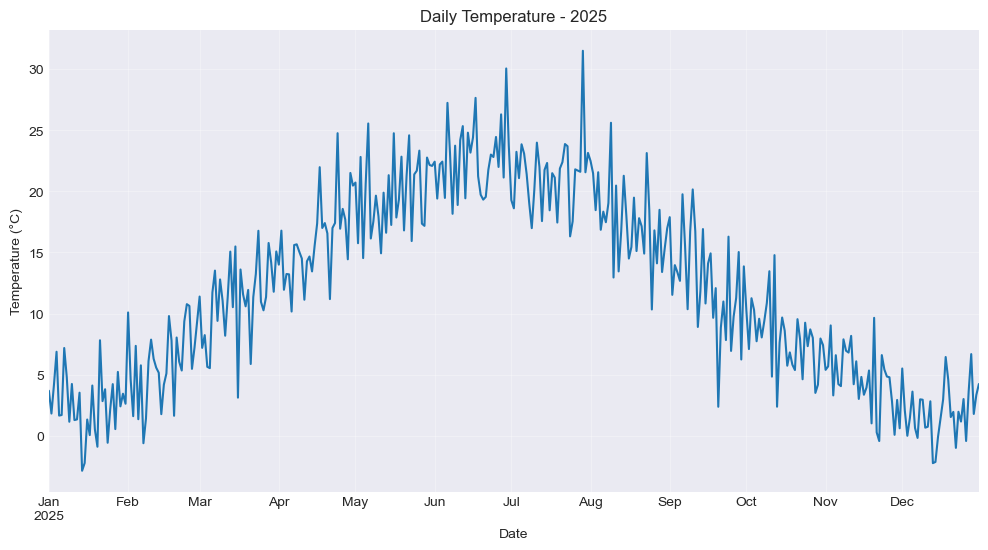

In [5]:
# Plot temperature over time
# The . plot() method creates a line plot by default
weather_df['temperature'].plot()

# Add labels and title
plt.title('Daily Temperature - 2025')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')

# Add a grid for easier reading
plt.grid(True, alpha=0.3)

# Display the plot
plt.show()

### 1.2 Customizing Line Plots

Add color, line style, and line width:

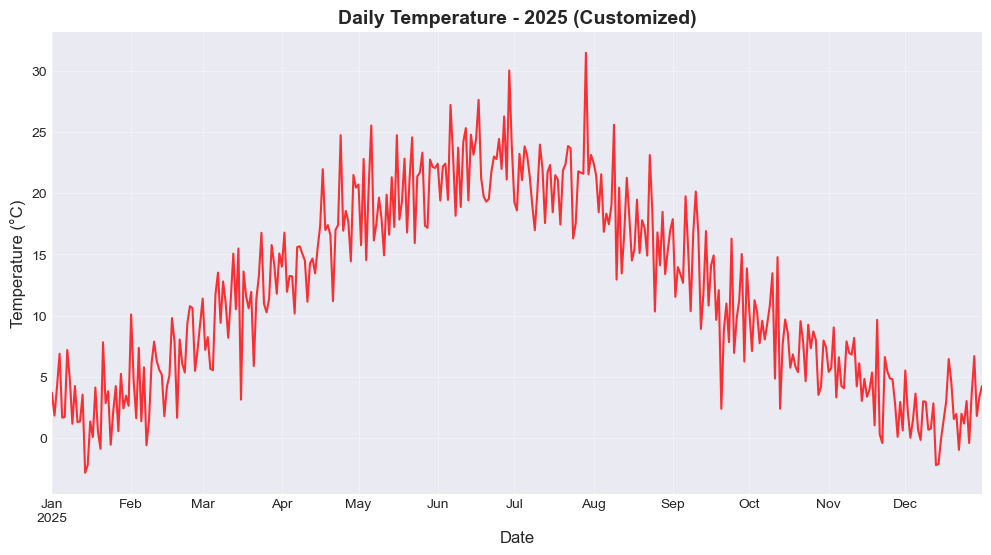

In [7]:
# Create a customized line plot
weather_df['temperature'].plot(
    kind='line',          # Plot type
    color='red',           # Line color
    linewidth=1.5,         # Line thickness
    linestyle='-',         # Line style:  '-' solid, '--' dashed, '-.' dash-dot, ': ' dotted
    alpha=0.8              # Transparency:  0 (transparent) to 1 (opaque)
)

plt.title('Daily Temperature - 2025 (Customized)', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

### 1.3 Plotting Multiple Variables

Show multiple variables on the same plot:

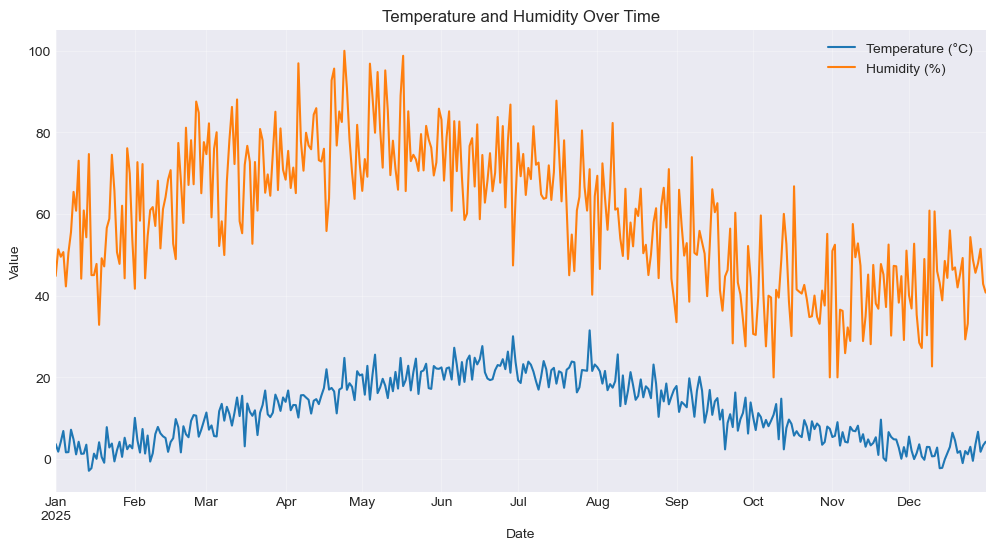

In [8]:
# Plot multiple columns at once
# Select only temperature and humidity (they have similar scales)
weather_df[['temperature', 'humidity']].plot()

plt.title('Temperature and Humidity Over Time')
plt.ylabel('Value')
plt.xlabel('Date')
plt.legend(['Temperature (°C)', 'Humidity (%)'])
plt.grid(True, alpha=0.3)

plt.show()

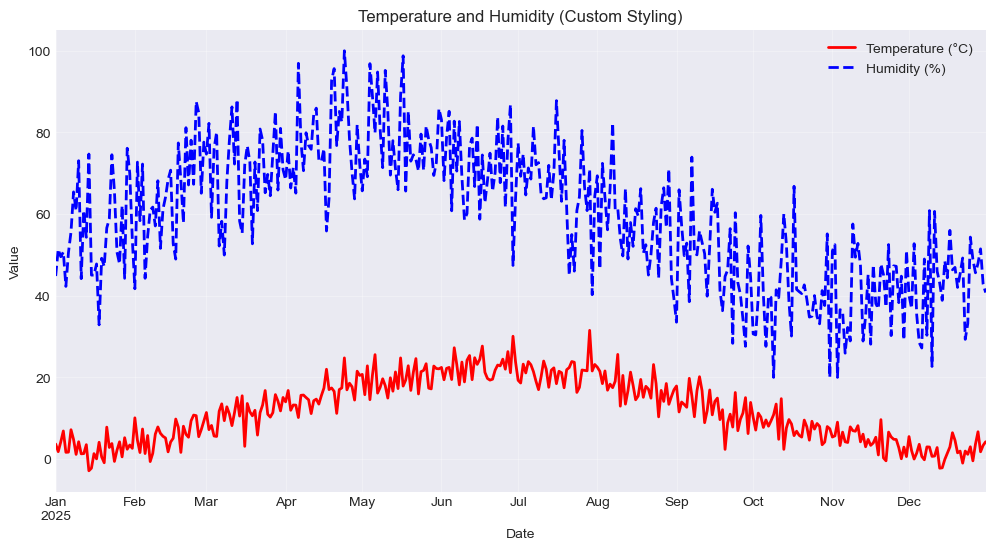

In [9]:
# Custom styling for multiple lines
weather_df[['temperature', 'humidity']].plot(
    style=['-', '--'],                    # Different line styles
    color=['red', 'blue'],                # Different colors
    linewidth=2                           # Line thickness
)

plt.title('Temperature and Humidity (Custom Styling)')
plt.ylabel('Value')
plt.xlabel('Date')
plt.legend(['Temperature (°C)', 'Humidity (%)'], loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

### 1.4 Zooming into a Time Period

Plot just a subset of the data:

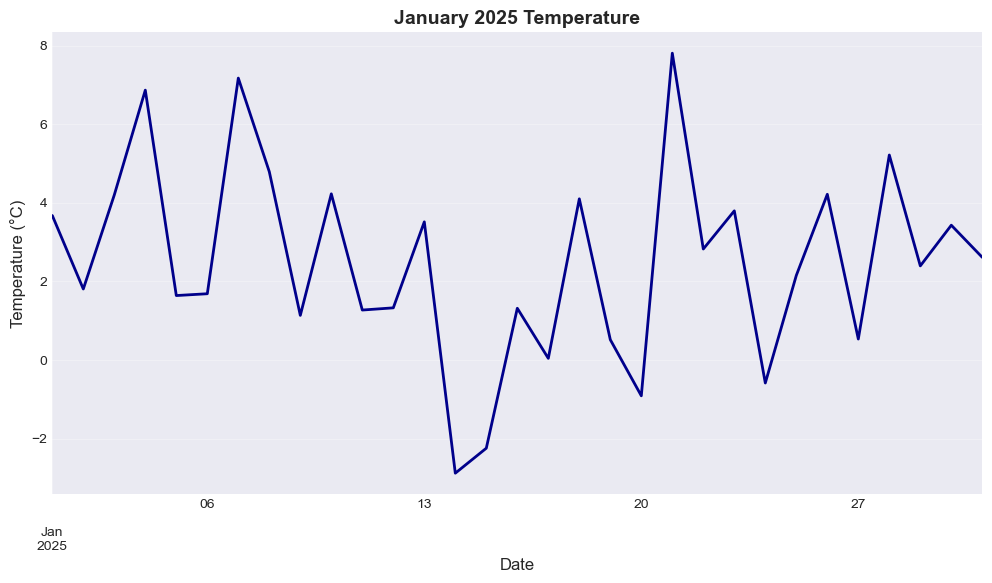

In [11]:
# Plot only January 2025
january_data = weather_df.loc['2025-01']

january_data['temperature'].plot(color='darkblue', linewidth=2)

plt.title('January 2025 Temperature', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

## Part 2: Scatter Plots

Scatter plots show the relationship between two variables.

### 2.1 Basic Scatter Plot

Explore the relationship between temperature and humidity:

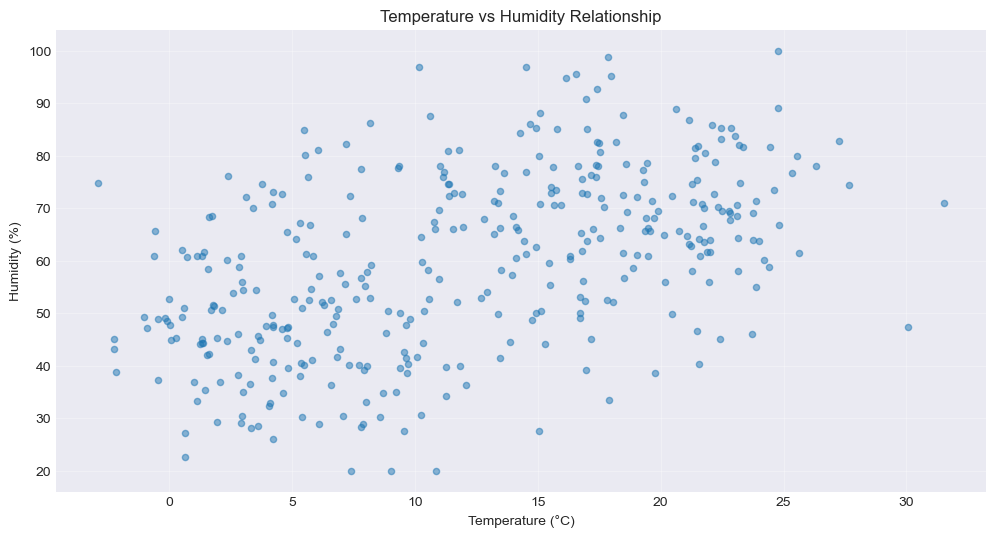

In [12]:
# Create scatter plot:  temperature vs humidity
weather_df.plot.scatter(
    x='temperature',       # Variable for x-axis
    y='humidity',          # Variable for y-axis
    alpha=0.5              # Transparency (helps see overlapping points)
)

plt.title('Temperature vs Humidity Relationship')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True, alpha=0.3)

plt.show()

### 2.2 Colored Scatter Plot

Use color to represent a third variable:

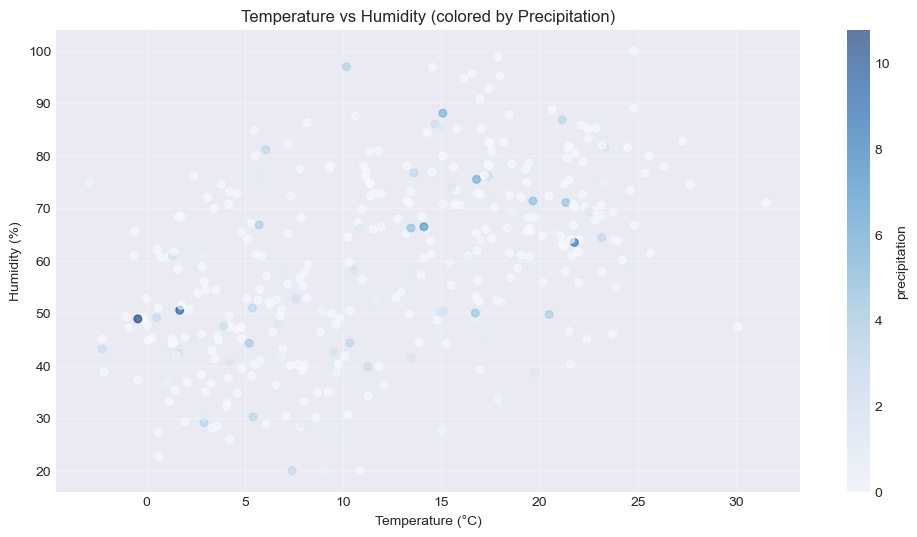

In [13]:
# Scatter plot with colors based on precipitation
weather_df.plot.scatter(
    x='temperature',
    y='humidity',
    c='precipitation',     # Color based on this variable
    cmap='Blues',          # Color map (Blues, Reds, Greens, viridis, etc.)
    s=30,                  # Size of points
    alpha=0.6,
    colorbar=True          # Show color scale bar
)

plt.title('Temperature vs Humidity (colored by Precipitation)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True, alpha=0.3)

plt.show()

### 2.3 Variable Sized Points

Point size can represent magnitude:

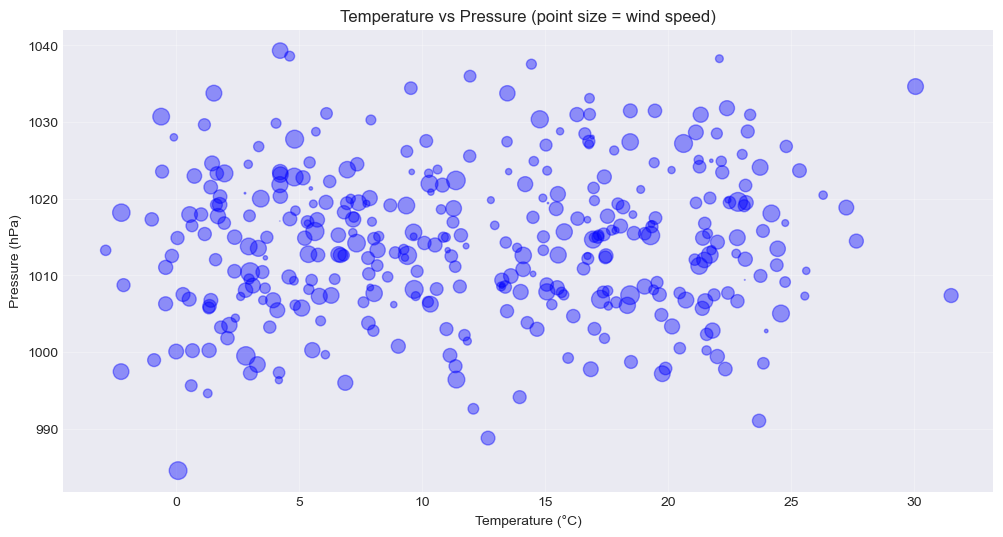

In [14]:
# Scatter plot with point size based on wind speed
weather_df.plot.scatter(
    x='temperature',
    y='pressure',
    s=weather_df['wind_speed'] * 10,  # Size based on wind speed (scaled by 10 for visibility)
    c='blue',
    alpha=0.4
)

plt.title('Temperature vs Pressure (point size = wind speed)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (hPa)')
plt.grid(True, alpha=0.3)

plt.show()

## Part 3: Bar Charts

Bar charts are great for comparing categories or showing aggregated data.

### 3.1 Monthly Average Temperature

Aggregate data and create a bar chart:

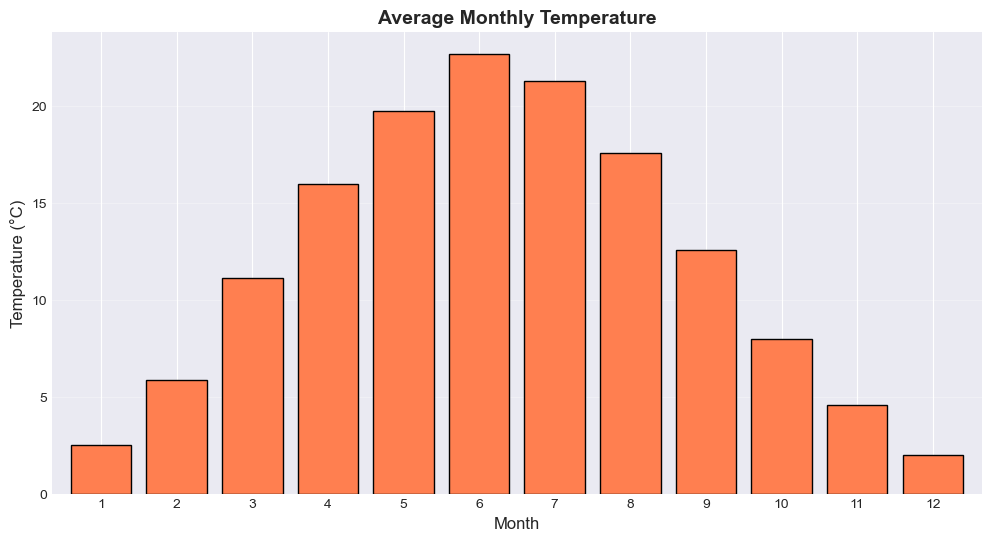

In [15]:
# Calculate monthly average temperature
monthly_temp = weather_df.groupby('month')['temperature'].mean()

# Create bar chart
monthly_temp.plot.bar(
    color='coral',         # Bar color
    edgecolor='black',     # Border color for bars
    width=0.8              # Bar width (0 to 1)
)

plt.title('Average Monthly Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=0)  # Keep month numbers horizontal
plt.grid(True, alpha=0.3, axis='y')  # Only horizontal grid lines

plt.show()

### 3.2 Grouped Bar Chart

Compare multiple variables side by side:

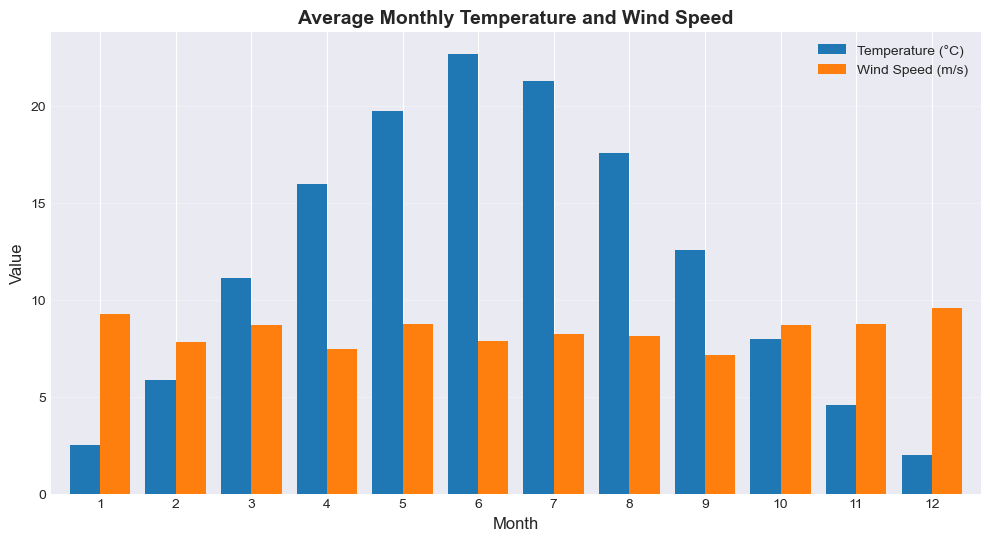

In [16]:
# Calculate monthly averages for multiple variables
monthly_stats = weather_df.groupby('month')[['temperature', 'wind_speed']].mean()

# Create grouped bar chart
monthly_stats.plot.bar(
    figsize=(12, 6),
    width=0.8
)

plt.title('Average Monthly Temperature and Wind Speed', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(['Temperature (°C)', 'Wind Speed (m/s)'])
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

plt.show()

### 3.3 Horizontal Bar Chart

Useful for ranked data or long labels:

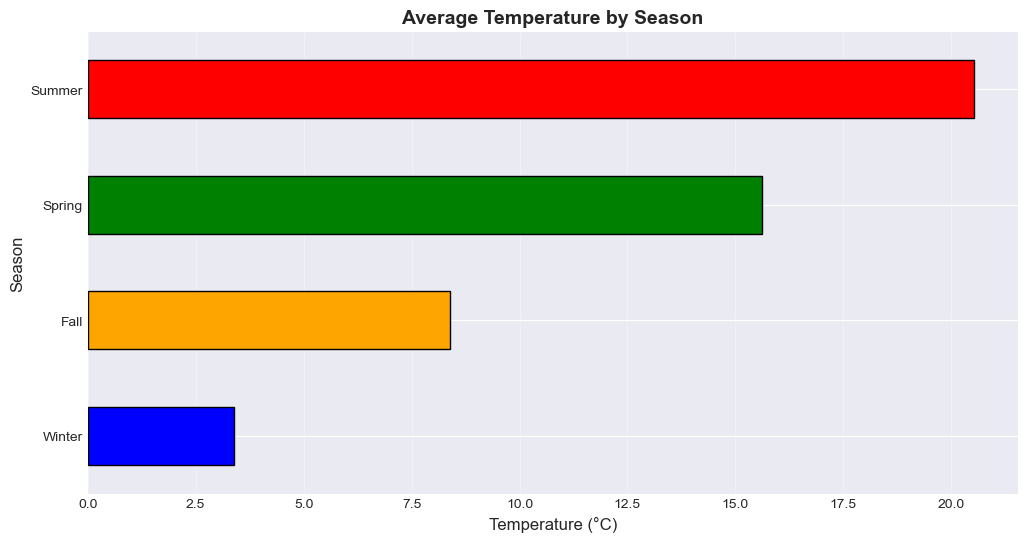

In [17]:
# Calculate average temperature by season
seasonal_temp = weather_df.groupby('season')['temperature'].mean().sort_values()

# Create horizontal bar chart
seasonal_temp.plot.barh(
    color=['blue', 'orange', 'green', 'red'],
    edgecolor='black'
)

plt.title('Average Temperature by Season', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Season', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

plt.show()

## Part 4: Histograms

Histograms show the distribution of a single variable.

### 4.1 Basic Histogram

Visualize temperature distribution:

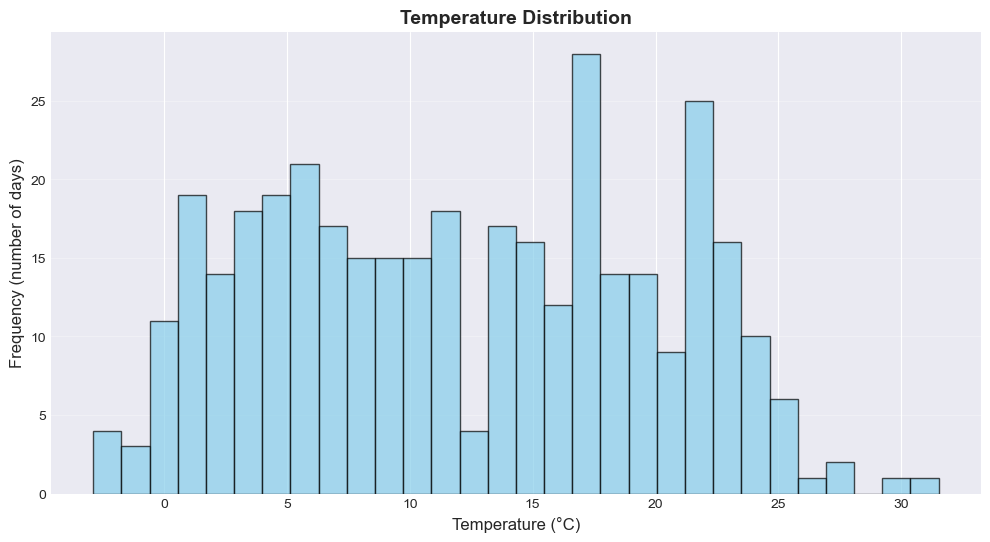

In [18]:
# Create histogram of temperature values
weather_df['temperature'].plot.hist(
    bins=30,               # Number of bins (bars)
    edgecolor='black',     # Border color
    alpha=0.7,             # Transparency
    color='skyblue'
)

plt.title('Temperature Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Frequency (number of days)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.show()

### 4.2 Multiple Histograms

Compare distributions:

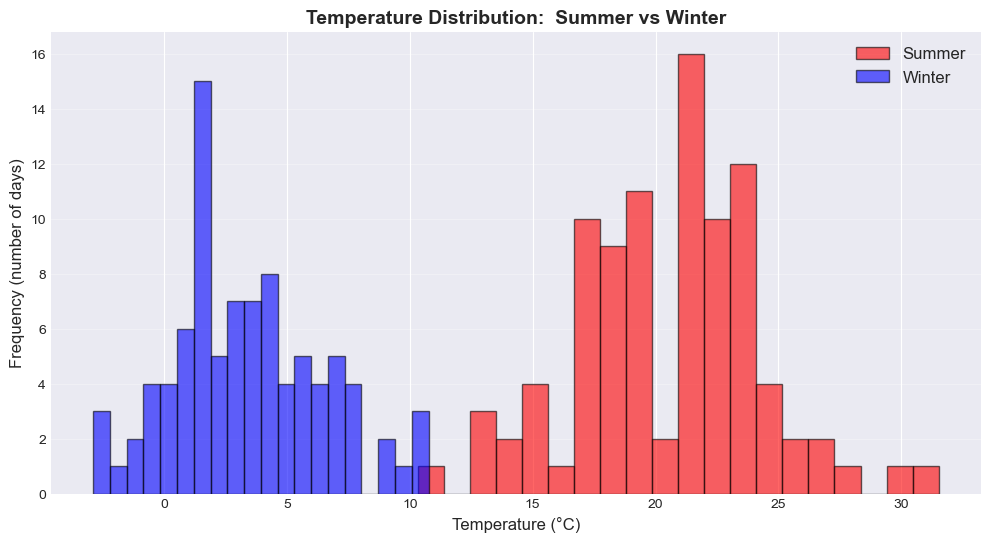

In [19]:
# Create separate histograms for summer and winter temperatures
summer_temps = weather_df[weather_df['season'] == 'Summer']['temperature']
winter_temps = weather_df[weather_df['season'] == 'Winter']['temperature']

# Plot both on the same axes
plt.figure(figsize=(12, 6))

plt.hist(summer_temps, bins=20, alpha=0.6, color='red', label='Summer', edgecolor='black')
plt.hist(winter_temps, bins=20, alpha=0.6, color='blue', label='Winter', edgecolor='black')

plt. title('Temperature Distribution:  Summer vs Winter', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Frequency (number of days)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.show()

### 4.3 Precipitation Distribution

Visualize only precipitation days:

Total rainy days:  99
Average rainfall on rainy days: 1.94 mm


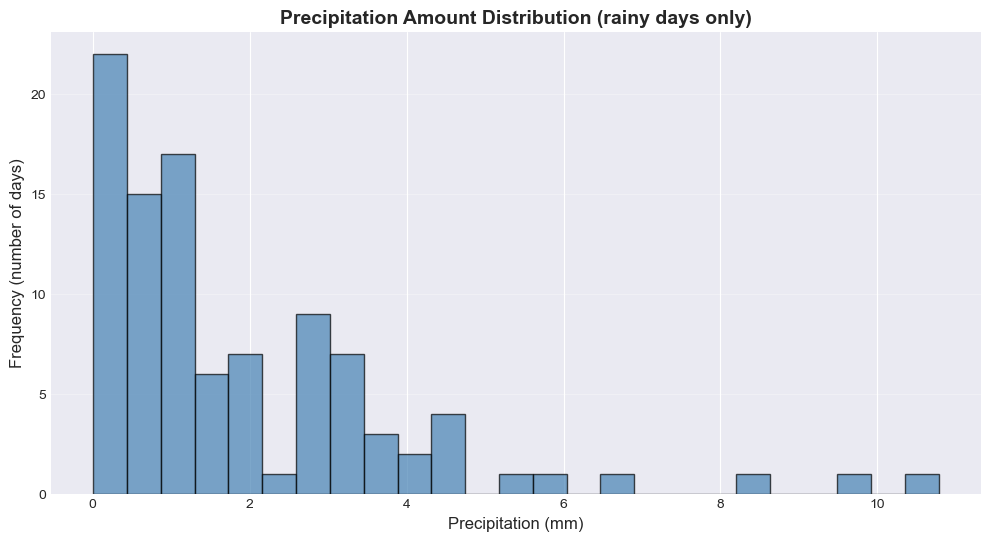

In [20]:
# Filter for days with precipitation
rainy_days = weather_df[weather_df['precipitation'] > 0]

# Plot distribution of precipitation amounts
rainy_days['precipitation'].plot.hist(
    bins=25,
    color='steelblue',
    edgecolor='black',
    alpha=0.7
)

plt. title('Precipitation Amount Distribution (rainy days only)', fontsize=14, fontweight='bold')
plt.xlabel('Precipitation (mm)', fontsize=12)
plt.ylabel('Frequency (number of days)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

print(f"Total rainy days:  {len(rainy_days)}")
print(f"Average rainfall on rainy days: {rainy_days['precipitation'].mean():.2f} mm")

plt.show()

## Part 5: Box Plots

Box plots show the distribution and identify outliers.

### 5.1 Single Variable Box Plot

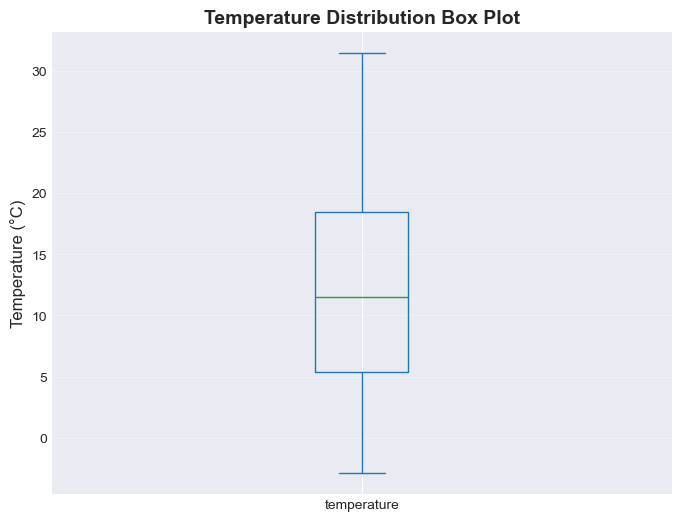

In [22]:
# Create box plot for temperature
weather_df[['temperature']].plot.box(
    figsize=(8, 6)  # Figure size
)

plt.title('Temperature Distribution Box Plot', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.show()

### 5.2 Multiple Variables Box Plot

Compare distributions of different variables:

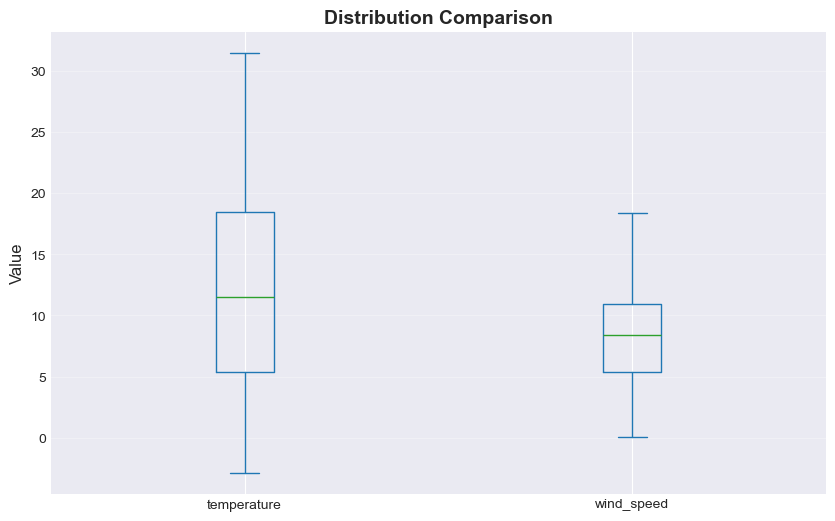

In [23]:
# Box plot for multiple variables
# Note: these variables have different scales, so comparison is difficult
weather_df[['temperature', 'wind_speed']].plot.box(
    figsize=(10, 6) # Figure size
)

plt.title('Distribution Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Value', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.show()

### 5.3 Seasonal Temperature Box Plot

Compare temperature distributions across seasons:

/var/folders/51/b9llyv5s4dd7llx0xjt1rzkw0000gr/T/ipykernel_60386/975267792.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(seasonal_data, labels=['Winter', 'Spring', 'Summer', 'Fall'])


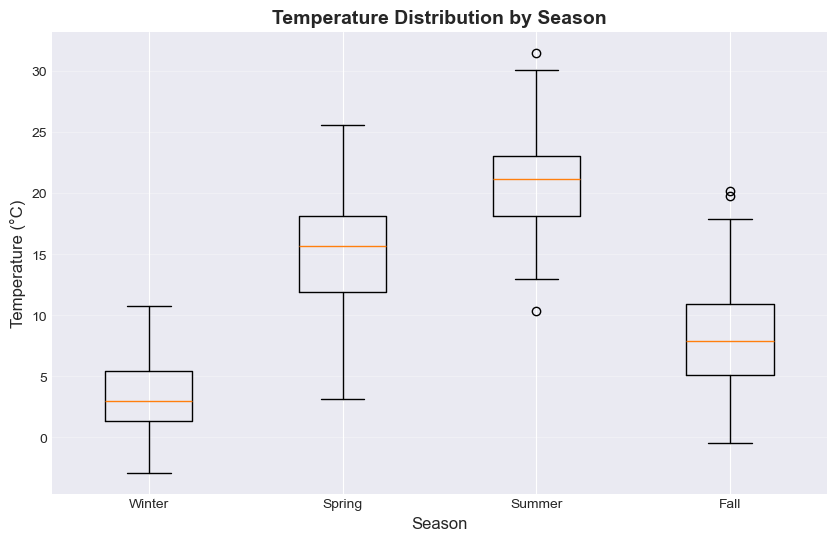

In [24]:
# Create box plot grouped by season
# First, create a pivot to organize data by season
seasonal_data = [weather_df[weather_df['season'] == season]['temperature'] for season in ['Winter', 'Spring', 'Summer', 'Fall']]

plt.figure(figsize=(10, 6))
plt.boxplot(seasonal_data, labels=['Winter', 'Spring', 'Summer', 'Fall'])

plt.title('Temperature Distribution by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.show()

## Part 6: Area Plots

Area plots are useful for showing cumulative values over time.

### 6.1 Cumulative Precipitation

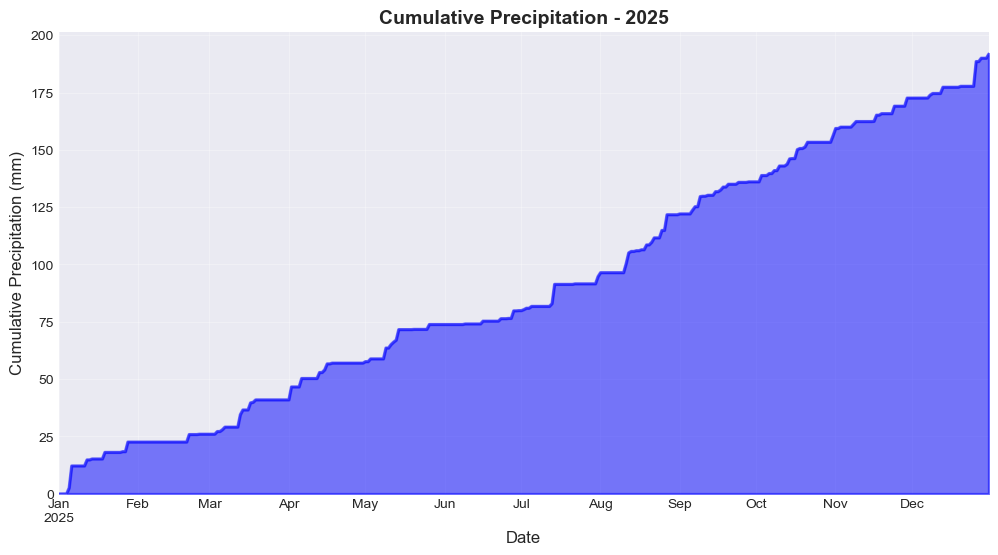

Total annual precipitation: 191.89 mm


In [27]:
# Calculate cumulative precipitation
weather_df['cumulative_precip'] = weather_df['precipitation'].cumsum()

# Create area plot
weather_df['cumulative_precip'].plot.area(
    color='blue',
    alpha=0.5,
    linewidth=2,
)

plt.title('Cumulative Precipitation - 2025', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Precipitation (mm)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

print(f"Total annual precipitation: {weather_df['cumulative_precip'].iloc[-1]:.2f} mm")

## Part 7: Multiple Subplots

Create dashboard-style layouts with multiple plots.

### 7.1 Using subplots Parameter

Automatically create separate subplots for each variable:

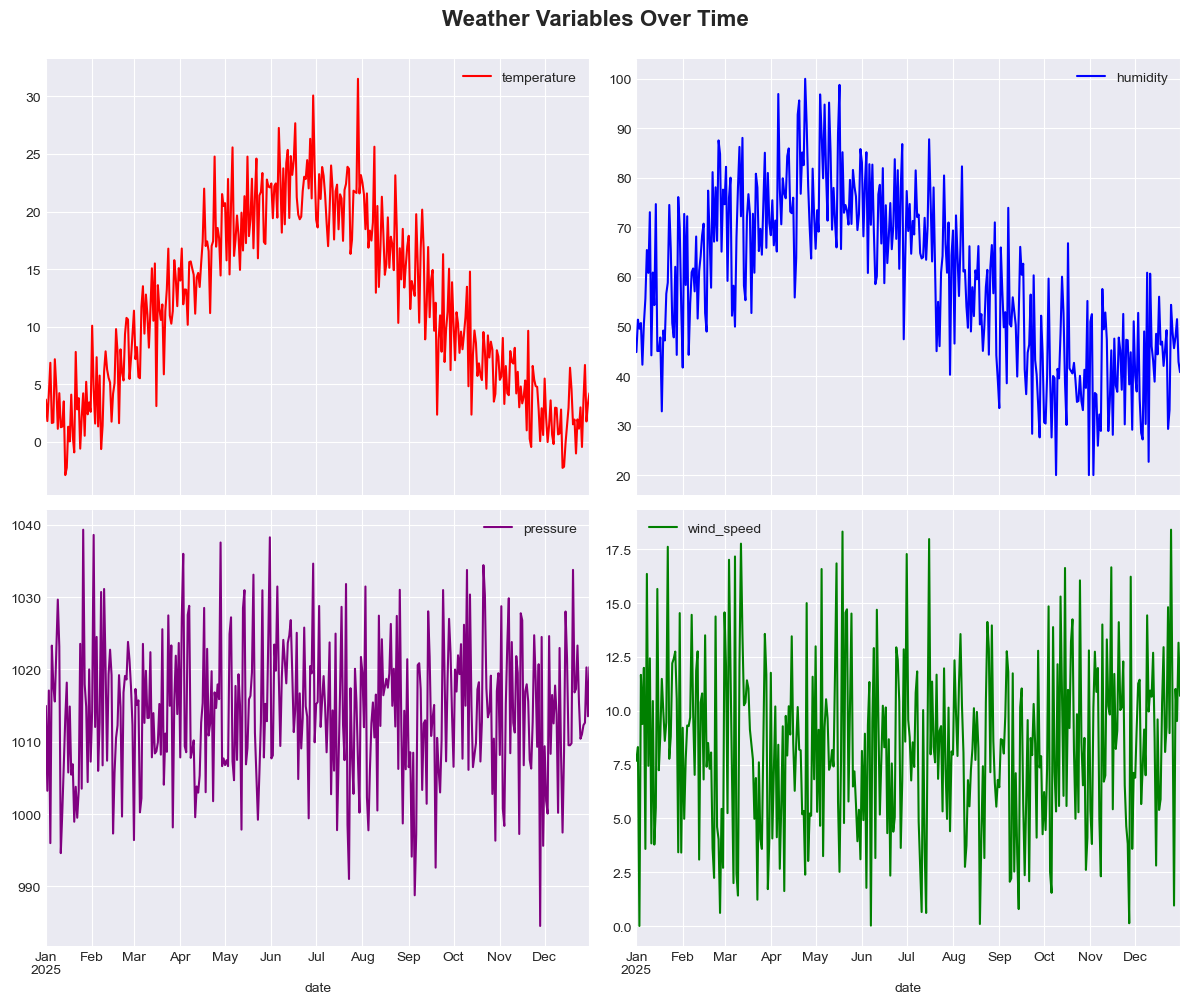

In [28]:
# Create subplots for multiple variables
# subplots=True creates a separate subplot for each column
weather_df[['temperature', 'humidity', 'pressure', 'wind_speed']].plot(
    subplots=True,         # Create separate subplot for each variable
    figsize=(12, 10),      # Overall figure size
    layout=(2, 2),         # Arrange in 2 rows x 2 columns
    sharex=True,           # Share x-axis (date) across all plots
    color=['red', 'blue', 'purple', 'green'],
    linewidth=1.5
)

plt.suptitle('Weather Variables Over Time', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()  # Adjust spacing to prevent overlap

plt.show()

### 7.2 Manual Subplot Creation

More control over individual subplots:

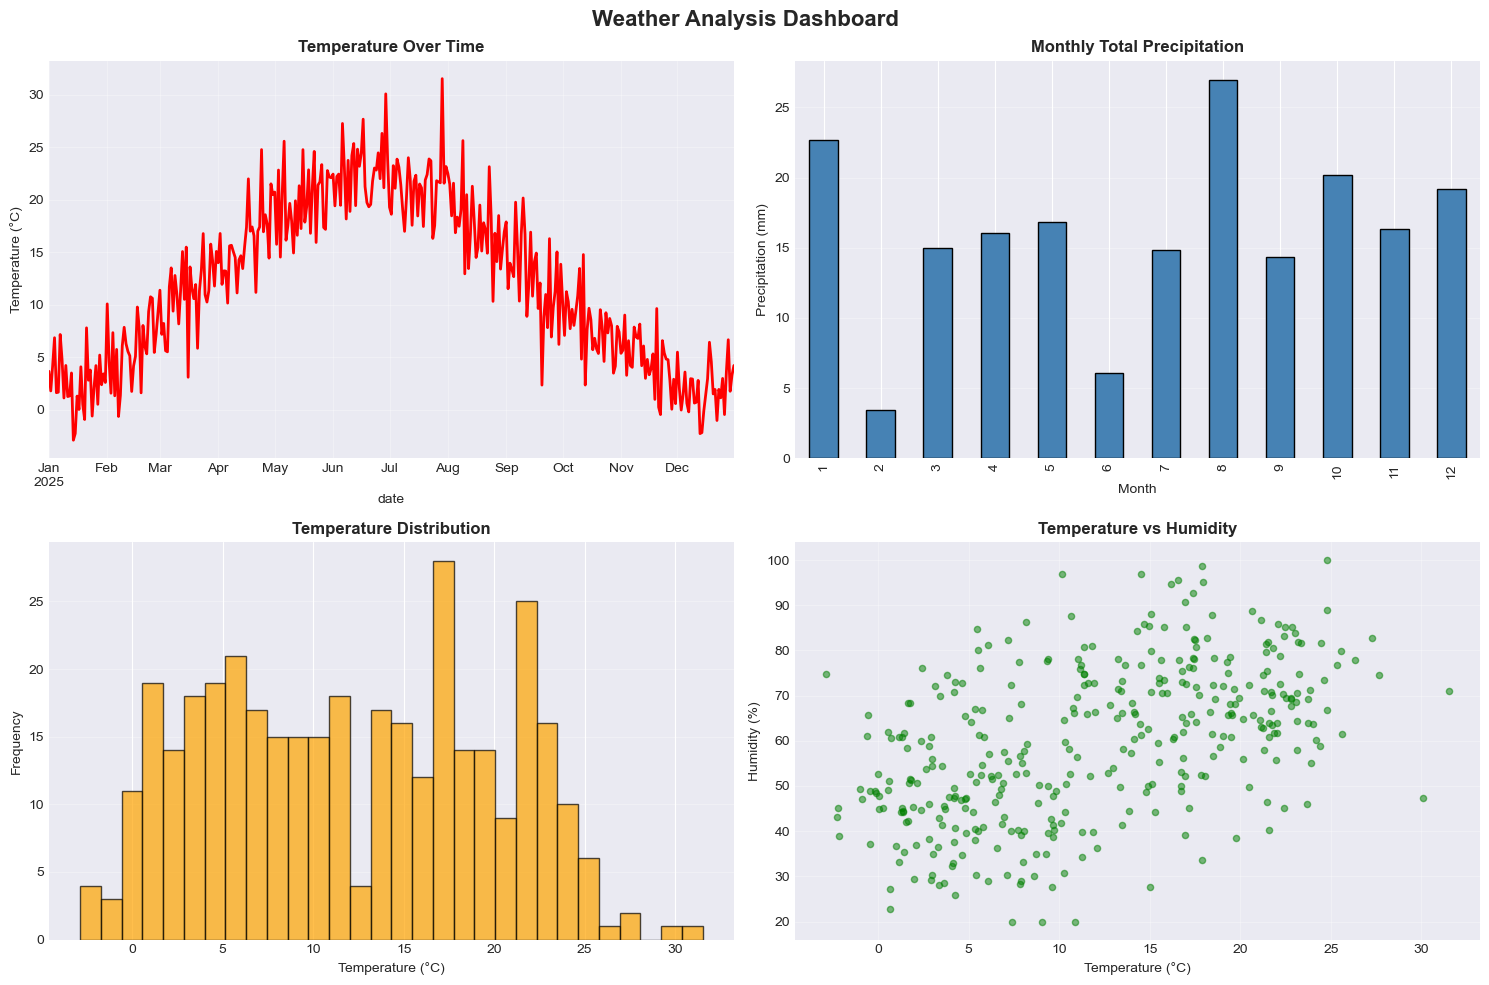

In [29]:
# Create figure with manual subplot layout
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Temperature time series (top-left)
weather_df['temperature'].plot(ax=axes[0, 0], color='red', linewidth=2)
axes[0, 0].set_title('Temperature Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Precipitation bar chart (top-right)
monthly_precip = weather_df. groupby('month')['precipitation'].sum()
monthly_precip.plot. bar(ax=axes[0, 1], color='steelblue', edgecolor='black')
axes[0, 1].set_title('Monthly Total Precipitation', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Precipitation (mm)')
axes[0, 1]. set_xlabel('Month')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Temperature histogram (bottom-left)
weather_df['temperature']. plot. hist(ax=axes[1, 0], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Temperature Distribution', fontsize=12, fontweight='bold')
axes[1, 0]. set_xlabel('Temperature (°C)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Temperature vs Humidity scatter (bottom-right)
weather_df.plot.scatter(x='temperature', y='humidity', ax=axes[1, 1], alpha=0.5, color='green')
axes[1, 1].set_title('Temperature vs Humidity', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Temperature (°C)')
axes[1, 1].set_ylabel('Humidity (%)')
axes[1, 1].grid(True, alpha=0.3)

# Main title for entire figure
fig.suptitle('Weather Analysis Dashboard', fontsize=16, fontweight='bold')

# Adjust layout to prevent overlap
plt. tight_layout()

plt.show()

## Part 8: Advanced Customization

### 8.1 Adding Reference Lines

Add horizontal or vertical lines to highlight thresholds:

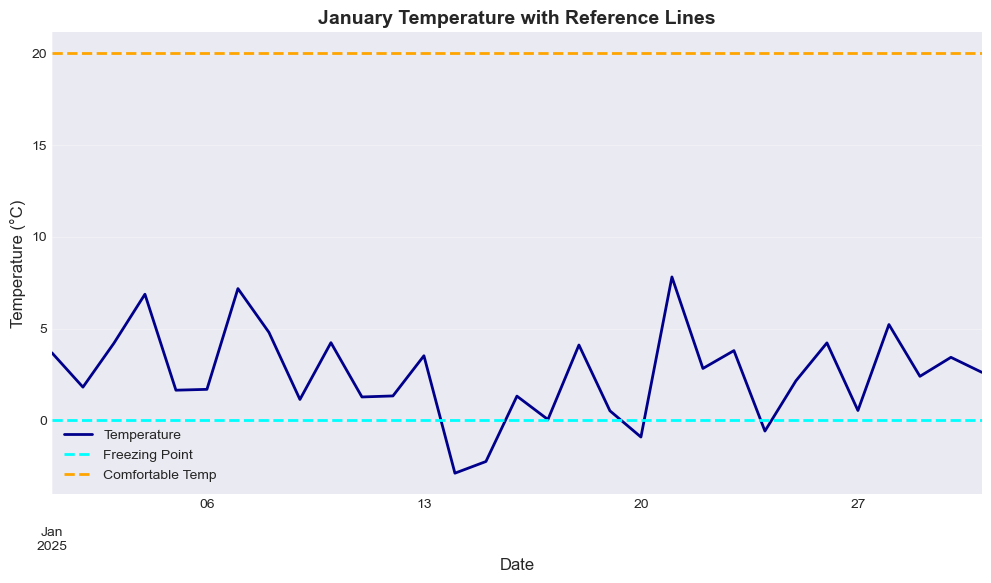

In [31]:
# Plot temperature with reference lines
january_data = weather_df.loc['2025-01']
january_data['temperature'].plot(color='darkblue', linewidth=2, label='Temperature')

# Add horizontal line at freezing point
plt.axhline(y=0, color='cyan', linestyle='--', linewidth=2, label='Freezing Point')

# Add horizontal line at comfortable temperature
plt.axhline(y=20, color='orange', linestyle='--', linewidth=2, label='Comfortable Temp')

plt.title('January Temperature with Reference Lines', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.show()

### 8.2 Adding Annotations

Highlight specific points or events:

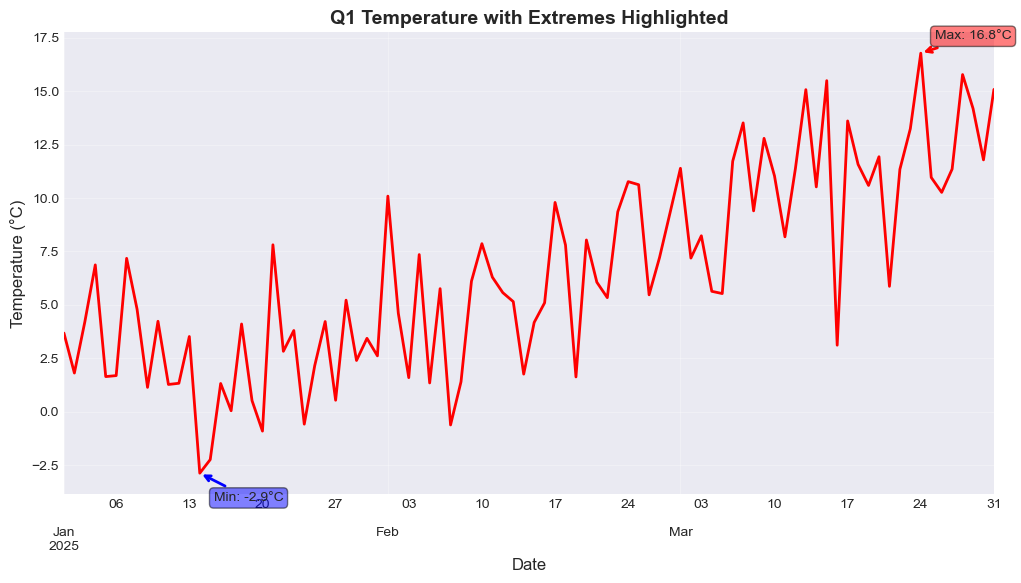

In [32]:
# Plot temperature for first quarter
q1_data = weather_df['2025-01':'2025-03']
q1_data['temperature'].plot(color='red', linewidth=2)

# Find the maximum temperature
max_temp = q1_data['temperature'].max()
max_date = q1_data['temperature'].idxmax()

# Find the minimum temperature
min_temp = q1_data['temperature'].min()
min_date = q1_data['temperature'].idxmin()

# Add annotation for maximum
plt.annotate(
    f'Max: {max_temp:.1f}°C',
    xy=(max_date, max_temp),              # Point to annotate
    xytext=(10, 10),                      # Offset of text (in points)
    textcoords='offset points',
    bbox=dict(boxstyle='round', facecolor='red', alpha=0.5),
    arrowprops=dict(arrowstyle='->', color='red', lw=2)
)

# Add annotation for minimum
plt.annotate(
    f'Min: {min_temp:.1f}°C',
    xy=(min_date, min_temp),
    xytext=(10, -20),
    textcoords='offset points',
    bbox=dict(boxstyle='round', facecolor='blue', alpha=0.5),
    arrowprops=dict(arrowstyle='->', color='blue', lw=2)
)

plt.title('Q1 Temperature with Extremes Highlighted', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

### 8.3 Dual Y-Axes

Plot two variables with different scales on the same chart:

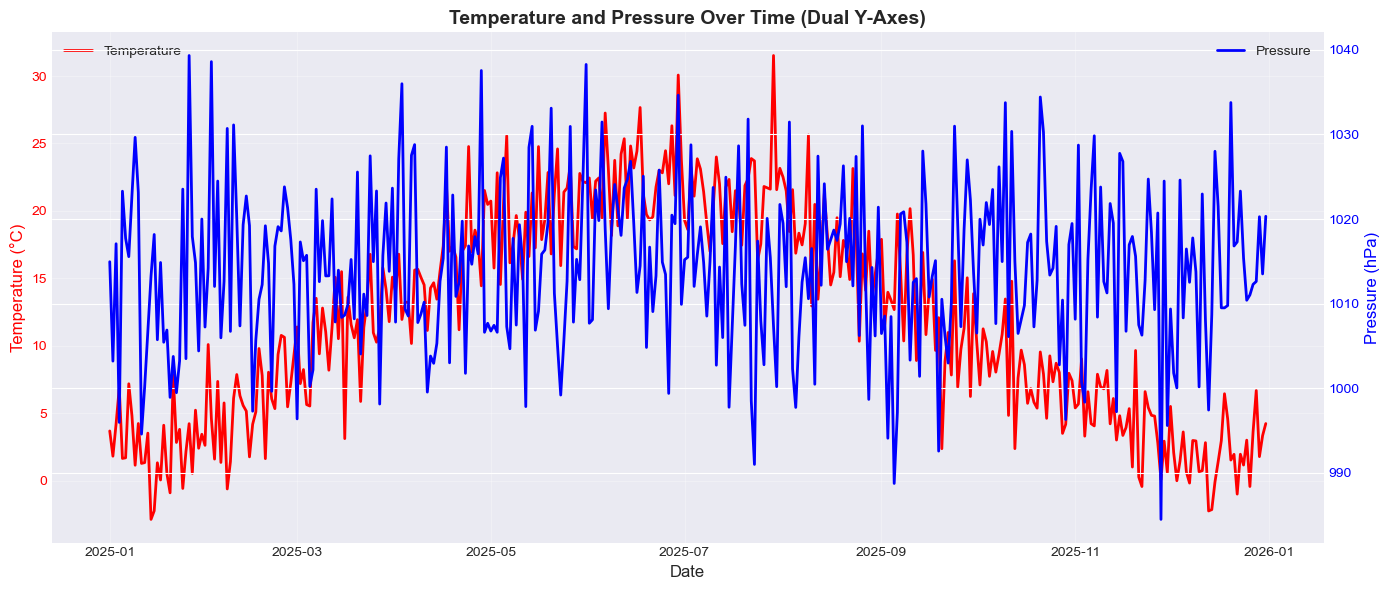

In [33]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot temperature on left y-axis
color = 'red'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color=color, fontsize=12)
ax1.plot(weather_df.index, weather_df['temperature'], color=color, linewidth=2, label='Temperature')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot pressure on right y-axis
color = 'blue'
ax2.set_ylabel('Pressure (hPa)', color=color, fontsize=12)
ax2.plot(weather_df.index, weather_df['pressure'], color=color, linewidth=2, label='Pressure')
ax2.tick_params(axis='y', labelcolor=color)

# Add title
plt.title('Temperature and Pressure Over Time (Dual Y-Axes)', fontsize=14, fontweight='bold')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 8.4 Filled Area Between Lines

Highlight ranges or differences:

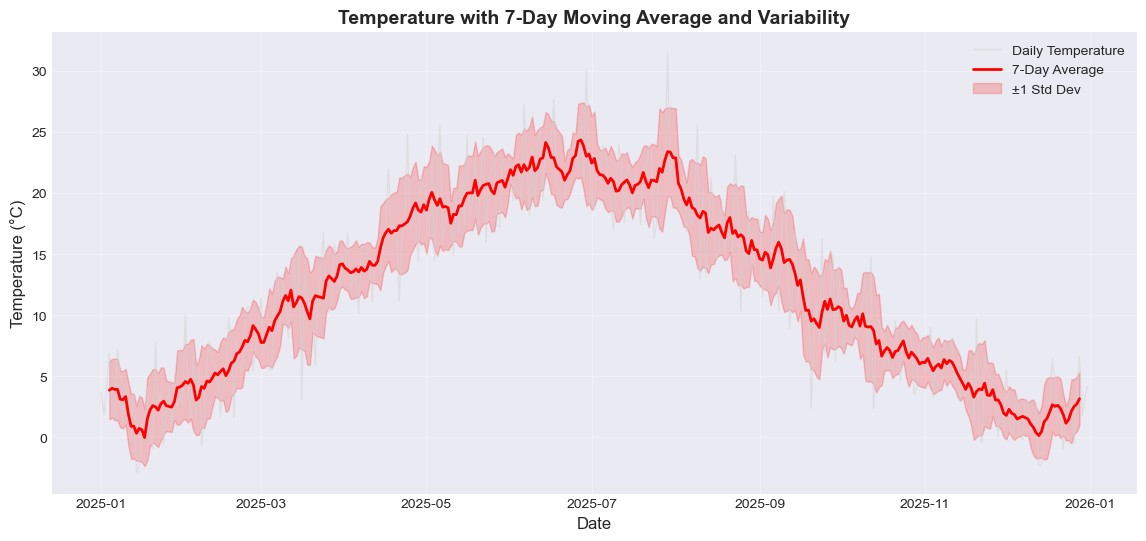

In [34]:
# Calculate 7-day rolling average and standard deviation
rolling_mean = weather_df['temperature'].rolling(window=7, center=True).mean()
rolling_std = weather_df['temperature'].rolling(window=7, center=True).std()

# Calculate upper and lower bounds (mean ± 1 std dev)
upper_bound = rolling_mean + rolling_std
lower_bound = rolling_mean - rolling_std

# Create the plot
plt.figure(figsize=(14, 6))

# Plot raw temperature data
plt.plot(weather_df.index, weather_df['temperature'], color='lightgray', alpha=0.5, linewidth=1, label='Daily Temperature')

# Plot rolling average
plt.plot(weather_df.index, rolling_mean, color='red', linewidth=2, label='7-Day Average')

# Fill area between upper and lower bounds
plt.fill_between(
    weather_df.index,
    lower_bound,
    upper_bound,
    color='red',
    alpha=0.2,
    label='±1 Std Dev'
)

plt.title('Temperature with 7-Day Moving Average and Variability', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.show()

## Part 9: Saving Plots

Export plots for reports and presentations.

### 9.1 Save to File

In [ ]:
# Create a plot
weather_df['temperature'].plot(color='red', linewidth=2)
plt.title('Annual Temperature - 2025', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)

# Save the figure
# Common formats: png, pdf, svg, jpg
plt.savefig(
    'temperature_plot.png',    # Filename
    dpi=300,                   # Resolution (dots per inch) - higher = better quality
    bbox_inches='tight',       # Remove extra whitespace
    facecolor='white'          # Background color
)

print("Plot saved as 'temperature_plot.png'")

plt.show()

In [ ]:
# Save in different formats
weather_df['temperature'].plot(color='red', linewidth=2)
plt.title('Annual Temperature - 2025', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3)

# Save as high-resolution PNG for reports
plt.savefig('temperature_high_res.png', dpi=300, bbox_inches='tight')

# Save as PDF for publications (vector format, scalable)
plt.savefig('temperature_plot.pdf', bbox_inches='tight')

# Save as SVG for web or further editing
plt.savefig('temperature_plot.svg', bbox_inches='tight')

print("Plots saved in multiple formats! ")

plt.show()

## Part 10: Meteorological Applications

### 10.1 Climatology Plot

Show daily climate normals with actual observations:

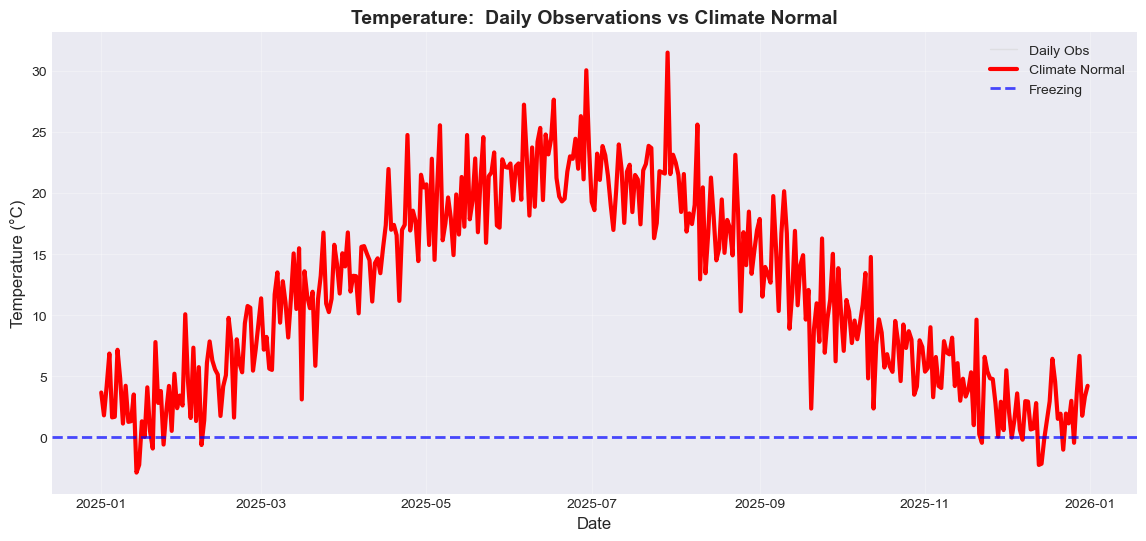

In [35]:
# Calculate climate normal (average by day of year)
weather_df['day_of_year'] = weather_df. index.dayofyear
climate_normal = weather_df.groupby('day_of_year')['temperature'].mean()

# Create plot
plt. figure(figsize=(14, 6))

# Plot actual daily temperatures (light)
plt.plot(weather_df.index, weather_df['temperature'], color='lightgray', alpha=0.5, linewidth=1, label='Daily Obs')

# Plot climate normal (smooth line)
plt.plot(weather_df.index, weather_df['day_of_year']. map(climate_normal), color='red', linewidth=3, label='Climate Normal')

# Add freezing line
plt. axhline(y=0, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='Freezing')

plt.title('Temperature:  Daily Observations vs Climate Normal', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.show()

### 10.2 Precipitation Analysis

Visualize precipitation patterns:

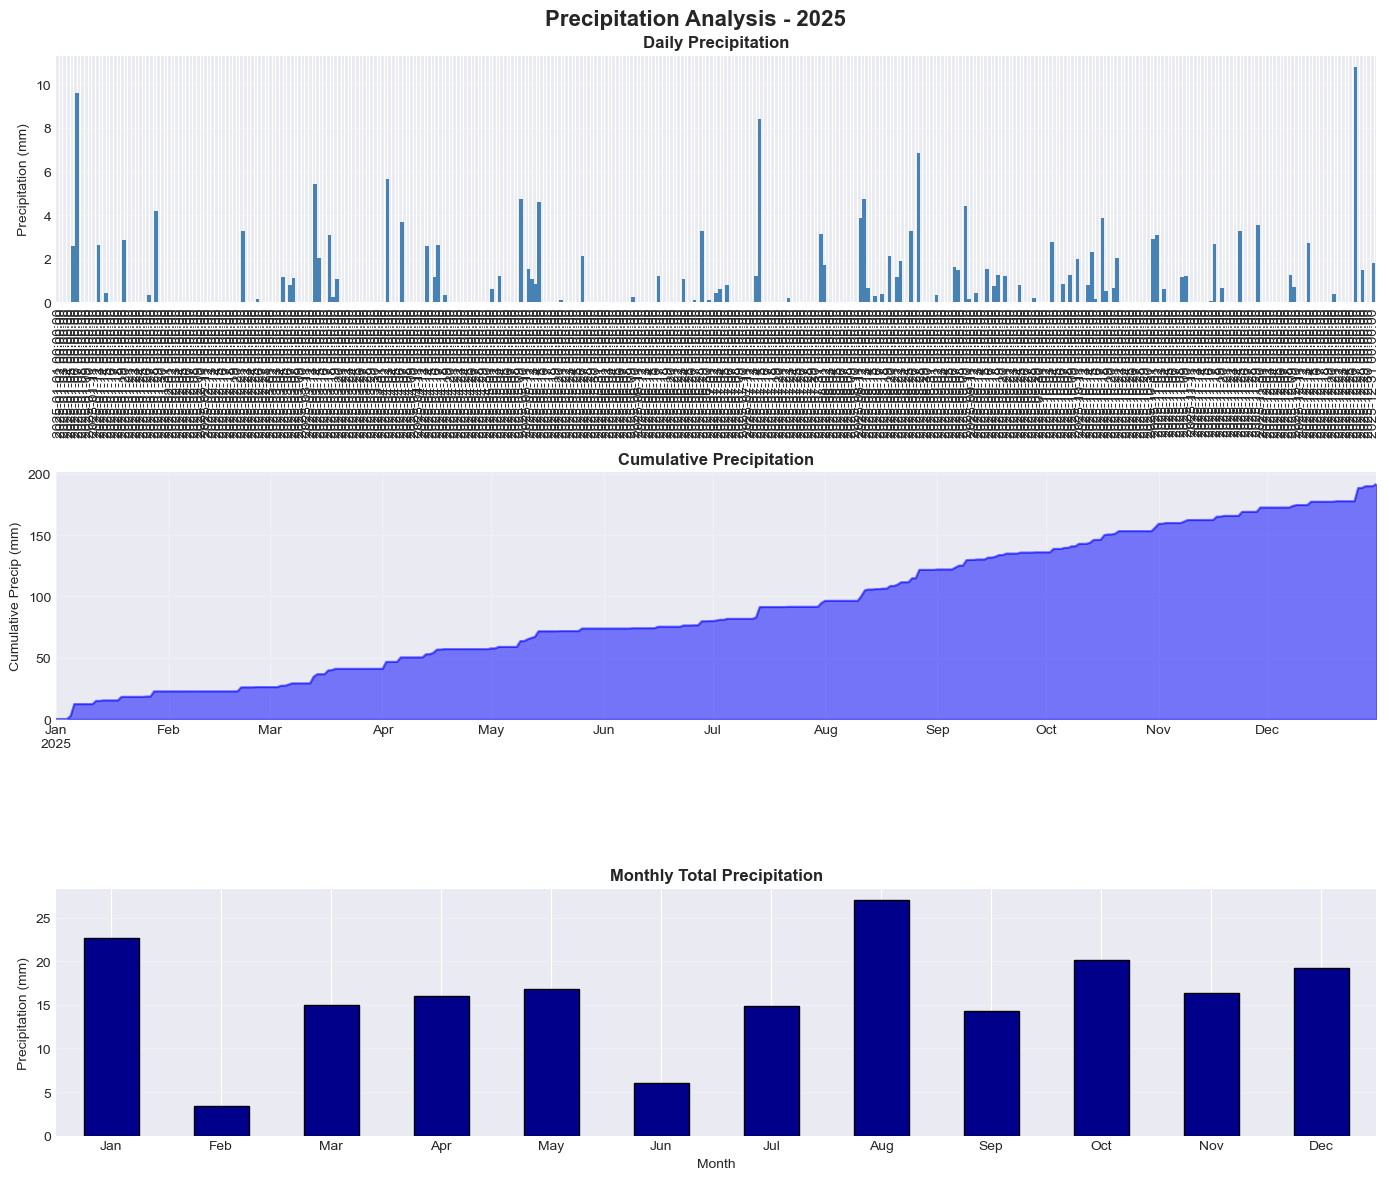

In [36]:
# Create multi-panel precipitation analysis
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Panel 1: Daily precipitation
weather_df['precipitation'].plot. bar(ax=axes[0], color='steelblue', width=1.0)
axes[0].set_title('Daily Precipitation', fontsize=12, fontweight='bold')
axes[0]. set_ylabel('Precipitation (mm)')
axes[0].set_xlabel('')
axes[0].grid(True, alpha=0.3, axis='y')

# Panel 2: Cumulative precipitation
weather_df['cumulative_precip']. plot.area(ax=axes[1], color='blue', alpha=0.5)
axes[1]. set_title('Cumulative Precipitation', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cumulative Precip (mm)')
axes[1].set_xlabel('')
axes[1].grid(True, alpha=0.3)

# Panel 3: Monthly totals
monthly_precip = weather_df. groupby('month')['precipitation'].sum()
monthly_precip.plot.bar(ax=axes[2], color='darkblue', edgecolor='black')
axes[2].set_title('Monthly Total Precipitation', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Precipitation (mm)')
axes[2].set_xlabel('Month')
axes[2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
axes[2].grid(True, alpha=0.3, axis='y')

fig.suptitle('Precipitation Analysis - 2025', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

### 10.3 Wind Rose (Simplified)

Create a simple wind speed distribution:

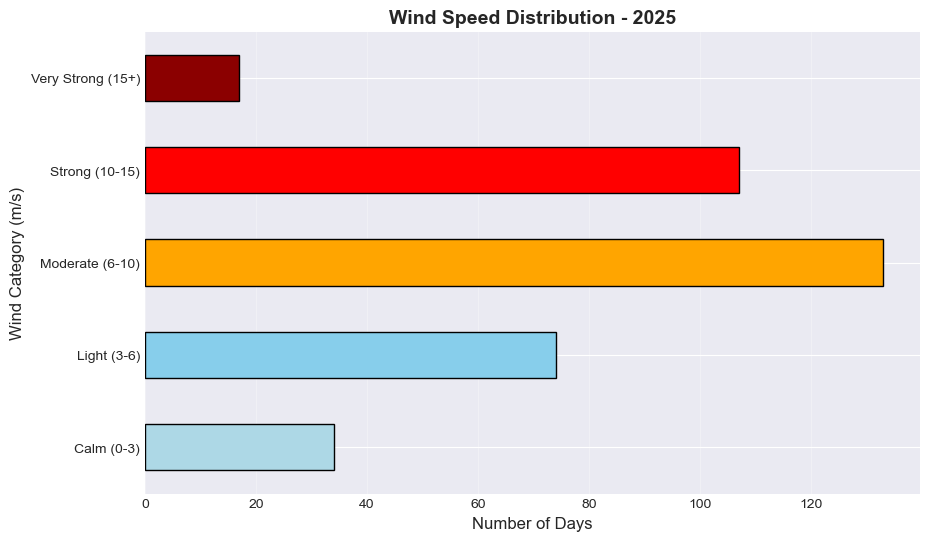


Wind speed statistics:
wind_speed
Calm (0-3)            34
Light (3-6)           74
Moderate (6-10)      133
Strong (10-15)       107
Very Strong (15+)     17
Name: count, dtype: int64


In [37]:
# Create wind speed categories
wind_categories = pd.cut(
    weather_df['wind_speed'],
    bins=[0, 3, 6, 10, 15, 25],
    labels=['Calm (0-3)', 'Light (3-6)', 'Moderate (6-10)', 'Strong (10-15)', 'Very Strong (15+)']
)

# Count occurrences in each category
wind_distribution = wind_categories.value_counts().sort_index()

# Create horizontal bar chart
wind_distribution.plot. barh(
    figsize=(10, 6),
    color=['lightblue', 'skyblue', 'orange', 'red', 'darkred'],
    edgecolor='black'
)

plt.title('Wind Speed Distribution - 2025', fontsize=14, fontweight='bold')
plt.xlabel('Number of Days', fontsize=12)
plt.ylabel('Wind Category (m/s)', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

plt.show()

print("\nWind speed statistics:")
print(wind_distribution)

### 10.4 Temperature Anomaly Plot

Show departures from normal:

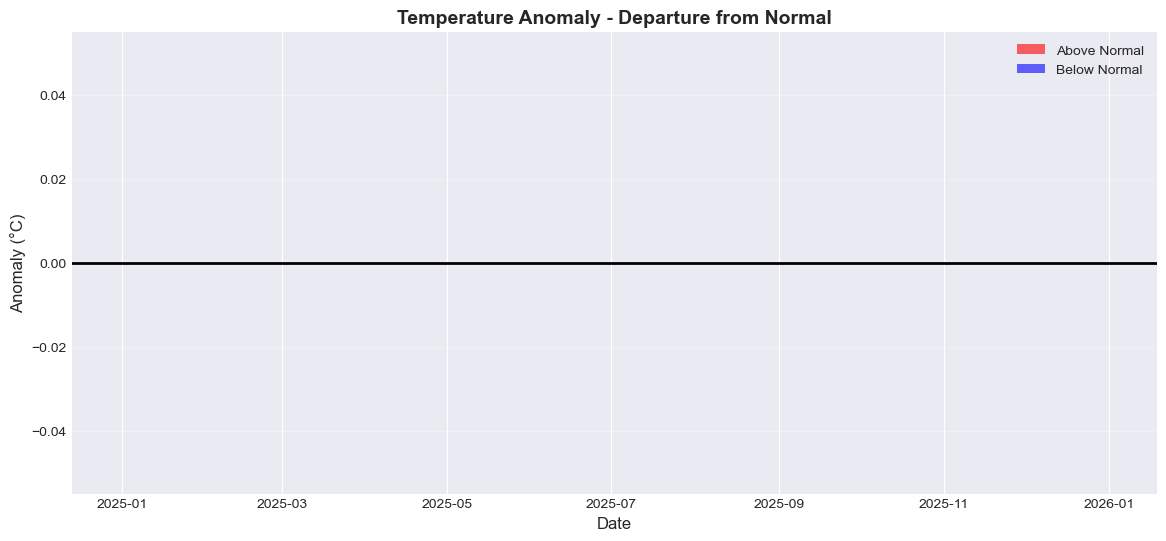

Average anomaly: 0.00°C
Largest warm anomaly: 0.00°C
Largest cold anomaly: 0.00°C


In [38]:
# Calculate temperature anomaly (departure from normal)
normal_temp = weather_df['day_of_year'].map(climate_normal)
weather_df['anomaly'] = weather_df['temperature'] - normal_temp

# Create anomaly plot with color coding
fig, ax = plt.subplots(figsize=(14, 6))

# Create bar plot where positive anomalies are red, negative are blue
colors = ['red' if x > 0 else 'blue' for x in weather_df['anomaly']]

ax.bar(weather_df.index, weather_df['anomaly'], color=colors, alpha=0.6, width=1)

# Add zero line
ax.axhline(y=0, color='black', linewidth=2)

plt.title('Temperature Anomaly - Departure from Normal', fontsize=14, fontweight='bold')
plt.ylabel('Anomaly (°C)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.6, label='Above Normal'),
    Patch(facecolor='blue', alpha=0.6, label='Below Normal')
]
ax.legend(handles=legend_elements, loc='best')

plt.show()

print(f"Average anomaly: {weather_df['anomaly'].mean():.2f}°C")
print(f"Largest warm anomaly: {weather_df['anomaly'].max():.2f}°C")
print(f"Largest cold anomaly: {weather_df['anomaly'].min():.2f}°C")

## Practice Exercises

Try these exercises to test your plotting skills:

### Exercise 1
Create a line plot showing wind speed for the month of July 2025. Add a horizontal line at 15 m/s to show the threshold for high wind warnings.

In [ ]:
# Your code here


### Exercise 2
Create a scatter plot showing the relationship between wind speed (x-axis) and pressure (y-axis). Color the points by temperature.

In [ ]:
# Your code here


### Exercise 3
Create a histogram showing the distribution of humidity values.  Use 25 bins and make the bars green with black edges.

In [ ]:
# Your code here


### Exercise 4
Create a 2x1 subplot layout showing:  (top) temperature over time as a line plot, and (bottom) a bar chart of average temperature by season.

In [ ]:
# Your code here


### Exercise 5
Create a plot showing the 30-day rolling average of temperature. Plot both the original daily temperatures (in light gray) and the rolling average (in dark red).

In [ ]:
# Your code here


## Quick Reference:  Plot Types and Methods

## Pandas Plot Types Quick Reference

| Plot Type       | Method                                    | Best Used For                                 |
|-----------------|-------------------------------------------|-----------------------------------------------|
| Line Plot       | `df.plot()` or `df.plot.line()`           | Time series, trends over time                 |
| Scatter Plot    | `df.plot.scatter(x=..., y=...)`           | Relationships between two variables           |
| Bar Chart       | `df.plot.bar()`                           | Comparing categories, aggregated data         |
| Horizontal Bar  | `df.plot.barh()`                          | Ranked data, long category names              |
| Histogram       | `df.plot.hist()`                          | Distribution of a single variable             |
| Box Plot        | `df.plot.box()`                           | Distribution summary, identifying outliers    |
| Area Plot       | `df.plot.area()`                          | Cumulative values, stacked variables          |
| Pie Chart       | `df.plot.pie()`                           | Proportions, percentages                      |


## Key Takeaways

- Pandas provides easy plotting methods for quick visualization
- Use `df.plot()` for line plots and `df.plot.scatter()` for scatter plots
- Customize with colors, labels, titles, and legends
- Create multiple subplots for dashboard-style visualizations
- Save plots as PNG, PDF, or SVG for reports
- Meteorological data benefits from time series and anomaly visualizations